In [21]:
%load_ext autoreload
%autoreload 2
# Set up GPU rendering.
# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl
import mujoco

# Other imports and helper functions
import numpy as np

from mujoco_irb120.util.load_obj_in_env import load_environment, load_photoshoot
from mujoco_irb120.controllers.controllers import PositionController
from mujoco_irb120.util.helper_fns import *
from mujoco_irb120.util.render_opts import RendererViewerOpts

# Graphics and plotting.
import mediapy as media
import matplotlib.pyplot as plt
import json as _json

%matplotlib ipympl

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)
# Set matplotlib font size
fonts = {'size' : 20}
plt.rc('font', **fonts)
# %matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl


#### (Optional) Keyboard Cartesian Control Setup
To enable interactive keyboard control of the robot end-effector:
- **Arrow Keys**: Move in X and Z directions
  - LEFT: Move -X (away from object)
  - RIGHT: Move +X (toward object)
  - UP: Move +Z (lift)
  - DOWN: Move -Z (lower)

Set `KEYBOARD_CONTROL = True` below to enable. Requires `VIZ = True` and focus on the viewer window.

In [22]:
# Enable/disable keyboard control toggle
KEYBOARD_CONTROL = True   # Set to False to disable keyboard control
print(f"Keyboard control: {'ENABLED' if KEYBOARD_CONTROL else 'DISABLED'}")
if KEYBOARD_CONTROL:
    print("  Controls: Arrow keys to move in X and Z directions")
    print("  Make sure viewer window has focus for keyboard input")

Keyboard control: ENABLED
  Controls: Arrow keys to move in X and Z directions
  Make sure viewer window has focus for keyboard input


## Main Simulation Loop

In [23]:
# ======================== Toggle visualization here =========================
VIZ = True   # set to False to record video without showing the viewer
# ============================================================================

## Let's reload the model to reset the simulation
# 0: box_exp, 10: heart, 11: L_shape, 12: monitor, 13: soda, 14: flashlight
OBJECT = 0
CONTROLLER_TYPE = "position"  # this notebook uses position control

model, data = load_environment(num=OBJECT, launch_viewer=False, controller_type=CONTROLLER_TYPE)

## =================== LOAD GROUND TRUTH PARAMS FROM JSON ===================
_obj_params = _json.load(open("../../assets/object_params.json"))["objects"][str(OBJECT)]

com_GT   = np.subtract(_obj_params["com_gt_onshape"], _obj_params["com_gt_offset"])
mass_GT     = _obj_params["mass_gt"]
init_xyz = np.array(_obj_params["init_xyz"])
## ===================================================================

## Setup based on robot model (new controller API)
irb = PositionController(model, data)

# Get initial EE pose (finger tip)
T_home = irb.FK()
print('Initial end-effector pose:\n', T_home)

## Set robot just in front of payload (same orientation as home position (facing +x))
T_init = T_home.copy()
T_init[:3, 3] = init_xyz.copy()

q_init = irb.IK(T_init, method=2, damping=0.5, max_iters=1000) # DLS method
irb.set_pose(q=q_init)

## The end pose we want to reach FOR POSITION CONTROL (format: 4x4 matrix)
T_end = T_init.copy()
T_end[0, 3] += 0.10  # Move EE forward by 10 cm in x direction

target_q = irb.IK(T_end, method=2, damping=0.5, max_iters=1000)  # DLS method

## TARE / Bias sensor
irb.ft_bias(n_samples=200)

## FOR VELOCITY CONTROL (format: [wx wy wz vx vy vz])
# target_vel  = np.array([0.0, 0.0, 0.0, 0.14, 0.0, 0.0])  # Move EE forward at 14 cm/s in x direction

## Initialize time, force and tilt history for plotting
t_hist          = []
w_hist          = []
quat_hist       = []
ball_pose_hist  = []  # (4,4) pose of ball-center site in world frame
sens_pose_hist  = []  # (4,4) pose of FT sensor site in world frame
con_bool_hist   = []  # contact flag
obj_pose_hist   = []  # (4,4) object pose in world frame (mj internal)

traj_duration = 6.0 # seconds
run_duration = traj_duration + 50.0

## Additions for video recording
rv = RendererViewerOpts(model, data, vis=VIZ, show_left_UI=True)
# ===========================================================================
with rv: # enters viewer if vis=True, sets viewer opts, and readies offscreen renderer for video capture
    while rv.viewer_is_running() and not irb.stop and data.time < run_duration:
        irb.check_topple()                          # Check for payload topple condition

        # Apply control: either keyboard-based or trajectory-based position control
        if KEYBOARD_CONTROL and VIZ:
            v_cmd = rv.get_keyboard_input()
            irb.apply_cartesian_keyboard_ctrl(v_cmd, maintain_orientation=True, verbose=False)
        else:
            if data.time < traj_duration:
                alpha = data.time / traj_duration
                interp_q = (1 - alpha) * q_init + alpha * target_q
            else:
                interp_q = target_q.copy()
            irb.set_pos_ctrl(interp_q, check_ellipsoid=False)

        mujoco.mj_step(model, data)                 # Step the simulation

        w_hist.append(irb.ft_get_reading())
        quat_hist.append(irb.get_payload_pose(out='quat'))
        t_hist.append(data.time)
        ball_pose_hist.append(irb.get_site_pose("ball"))
        sens_pose_hist.append(irb.get_site_pose("sensor"))
        con_bool_hist.append(irb.check_contact())
        obj_pose_hist.append(irb.get_payload_pose(out='T'))

        rv.sync()
        rv.capture_frame_if_due(data)

t_hist          = np.asarray(t_hist,         dtype=float)
quat_hist       = np.asarray(quat_hist,      dtype=float)
con_bool_hist   = np.asarray(con_bool_hist,  dtype=float)
w_hist          = np.asarray(w_hist,         dtype=float).reshape(-1, 6)
ball_pose_hist  = np.asarray(ball_pose_hist, dtype=float).reshape(-1, 4, 4)
sens_pose_hist  = np.asarray(sens_pose_hist, dtype=float).reshape(-1, 4, 4)
obj_pose_hist   = np.asarray(obj_pose_hist,  dtype=float).reshape(-1, 4, 4)

ball_pos_hist = ball_pose_hist[:, :3, 3]
sens_pos_hist = sens_pose_hist[:, :3, 3]
obj_pos_hist  = obj_pose_hist[:,  :3, 3]

print(f'\nSimulation ended in t = {data.time:.2f} seconds.')
media.show_video(rv.frames, fps=rv.framerate)

Initial end-effector pose:
 [[1.    0.    0.    0.374]
 [0.    1.    0.    0.   ]
 [0.    0.    1.    0.665]
 [0.    0.    0.    1.   ]]
Biasing F/T sensor with 200 static samples...
Force offset: [-0.    -1.256  0.     0.089 -0.    -0.   ]

Simulation ended in t = 1.63 seconds.


This browser does not support the video tag.


## Perception Loop: Depth Camera -> Point Cloud
This section reads depth from the fixed MuJoCo camera (`depth_cam`), reconstructs a world-frame point cloud, and visualizes it to verify object geometry.

In [24]:
# Depth -> point cloud helpers for a fixed MuJoCo camera
from pathlib import Path
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed by matplotlib 3D projection)

PC_CAM_NAME = "depth_cam"
PC_W = 640
PC_H = 480
PC_STRIDE = 1      # keep all pixels; downsample with random sampling instead
PC_Z_MIN = 0.05    # meters
PC_Z_MAX = 2.5     # meters
PC_MAX_POINTS = 12000

pc_renderer = mujoco.Renderer(model, height=PC_H, width=PC_W)

def _get_camera_pose_world(model, data, cam_name: str):
    cam_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_CAMERA, cam_name)
    if cam_id < 0:
        raise ValueError(f"Camera '{cam_name}' not found in model.")
    mujoco.mj_forward(model, data)
    R_wc = data.cam_xmat[cam_id].reshape(3, 3).copy()
    p_wc = data.cam_xpos[cam_id].copy()
    return R_wc, p_wc, cam_id

def _get_intrinsics_from_fovy(model, cam_id: int, width: int, height: int):
    fovy_rad = np.deg2rad(float(model.cam_fovy[cam_id]))
    fy = 0.5 * height / np.tan(0.5 * fovy_rad)
    fx = fy  # assume square pixels
    cx = (width - 1) * 0.5
    cy = (height - 1) * 0.5
    return fx, fy, cx, cy

def _normalize_depth_to_meters(model, raw_depth):
    # MuJoCo Python renderer may return either metric depth or normalized depth buffer.
    # Detect and convert normalized [0, 1] values to meters using near/far plane.
    d = raw_depth.astype(np.float32)
    if np.nanmax(d) <= 1.001:
        near = float(model.vis.map.znear) * float(model.stat.extent)
        far = float(model.vis.map.zfar) * float(model.stat.extent)
        d = near / (1.0 - d * (1.0 - near / far))
    return d

def capture_depth_image(model, data, renderer, cam_name: str):
    renderer.enable_depth_rendering()
    renderer.update_scene(data, camera=cam_name)
    raw_depth = renderer.render().copy()
    renderer.disable_depth_rendering()
    return _normalize_depth_to_meters(model, raw_depth)

def capture_segmentation(renderer, data, cam_name: str):
    renderer.enable_segmentation_rendering()
    renderer.update_scene(data, camera=cam_name)
    seg = renderer.render().copy()
    renderer.disable_segmentation_rendering()
    return seg

def _geom_mask_from_seg(seg, geom_id: int):
    # MuJoCo segmentation commonly returns per-pixel [objtype, objid]
    # but channel order can vary by backend/version; handle both.
    if seg.ndim != 3 or seg.shape[2] < 2:
        return np.ones(seg.shape[:2], dtype=bool)

    a = seg[:, :, 0]
    b = seg[:, :, 1]
    geom_type = int(mujoco.mjtObj.mjOBJ_GEOM)

    mask_ab = (a == geom_type) & (b == geom_id)
    mask_ba = (b == geom_type) & (a == geom_id)

    if np.count_nonzero(mask_ab) > 0:
        return mask_ab
    if np.count_nonzero(mask_ba) > 0:
        return mask_ba

    return np.zeros(seg.shape[:2], dtype=bool)

def depth_to_world_pointcloud(
    depth, R_wc, p_wc, fx, fy, cx, cy,
    stride=1, z_min=0.05, z_max=3.0, pixel_mask=None, max_points=None,
):
    if stride > 1:
        depth = depth[::stride, ::stride]
        if pixel_mask is not None:
            pixel_mask = pixel_mask[::stride, ::stride]

    h, w = depth.shape
    uu, vv = np.meshgrid(np.arange(w), np.arange(h))

    # Adjust principal point and focal lengths when using striding
    cx_s = cx / stride
    cy_s = cy / stride
    fx_s = fx / stride
    fy_s = fy / stride

    z = depth.astype(np.float32)
    valid = np.isfinite(z) & (z > z_min) & (z < z_max)
    if pixel_mask is not None:
        valid &= pixel_mask

    valid_idx = np.flatnonzero(valid.ravel())
    if valid_idx.size == 0:
        return np.empty((0, 3), dtype=np.float32)

    if max_points is not None and valid_idx.size > int(max_points):
        valid_idx = np.random.choice(valid_idx, size=int(max_points), replace=False)

    uu_f = uu.ravel()[valid_idx].astype(np.float32)
    vv_f = vv.ravel()[valid_idx].astype(np.float32)
    z_f = z.ravel()[valid_idx]

    x = (uu_f - cx_s) * z_f / fx_s
    y = (vv_f - cy_s) * z_f / fy_s

    # MuJoCo/OpenGL camera convention: forward is -Z in camera frame.
    # Also flip image-y to map image row-down to camera +Y up.
    pts_cam = np.stack([x, -y, -z_f], axis=1)

    pts_world = (R_wc @ pts_cam.T).T + p_wc.reshape(1, 3)
    return pts_world

print(f"Perception helpers ready. Fixed camera='{PC_CAM_NAME}'")

Perception helpers ready. Fixed camera='depth_cam'


Depth shape: (480, 640)
Scene point count: 12000
Object point count: 12000 (geom id=12)


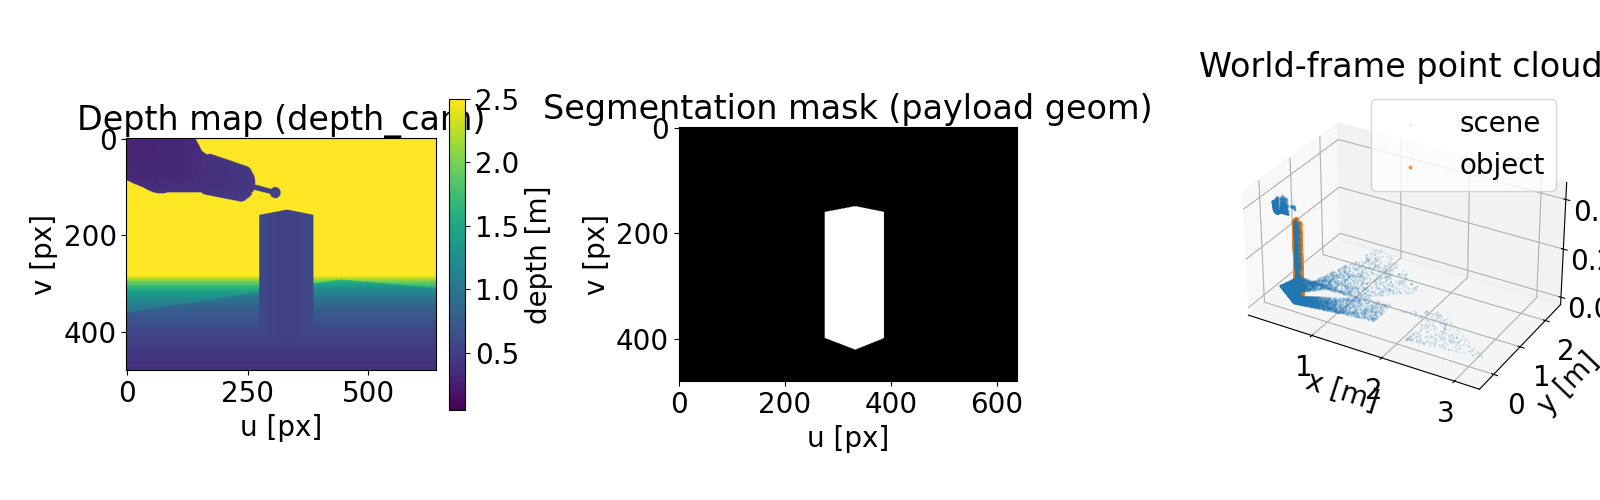

In [25]:
# Single-frame capture + visualization (scene cloud + object-only cloud)
R_wc, p_wc, cam_id = _get_camera_pose_world(model, data, PC_CAM_NAME)
fx, fy, cx, cy = _get_intrinsics_from_fovy(model, cam_id, PC_W, PC_H)

depth_img = capture_depth_image(model, data, pc_renderer, PC_CAM_NAME)
seg_img = capture_segmentation(pc_renderer, data, PC_CAM_NAME)

# Resolve target geom id for box/object masking
try:
    target_geom_id = model.geom('payload').id
except Exception:
    target_geom_id = model.ngeom - 1

obj_mask = _geom_mask_from_seg(seg_img, target_geom_id)

pc_world_scene = depth_to_world_pointcloud(
    depth_img, R_wc, p_wc, fx, fy, cx, cy,
    stride=PC_STRIDE, z_min=PC_Z_MIN, z_max=PC_Z_MAX, pixel_mask=None, max_points=PC_MAX_POINTS,
    )
pc_world_obj = depth_to_world_pointcloud(
    depth_img, R_wc, p_wc, fx, fy, cx, cy,
    stride=PC_STRIDE, z_min=PC_Z_MIN, z_max=PC_Z_MAX, pixel_mask=obj_mask, max_points=PC_MAX_POINTS,
    )

print(f"Depth shape: {depth_img.shape}")
print(f"Scene point count: {pc_world_scene.shape[0]}")
print(f"Object point count: {pc_world_obj.shape[0]} (geom id={target_geom_id})")

fig = plt.figure(figsize=(16, 5))

ax1 = fig.add_subplot(1, 3, 1)
im = ax1.imshow(depth_img, cmap='viridis', vmin=PC_Z_MIN, vmax=min(PC_Z_MAX, np.nanpercentile(depth_img, 99)))
ax1.set_title(f"Depth map ({PC_CAM_NAME})")
ax1.set_xlabel("u [px]")
ax1.set_ylabel("v [px]")
plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label="depth [m]")

ax2 = fig.add_subplot(1, 3, 2)
ax2.imshow(obj_mask, cmap='gray')
ax2.set_title("Segmentation mask (payload geom)")
ax2.set_xlabel("u [px]")
ax2.set_ylabel("v [px]")

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
if pc_world_scene.shape[0] > 0:
    p_scene = pc_world_scene
    ax3.scatter(p_scene[:, 0], p_scene[:, 1], p_scene[:, 2], s=0.4, alpha=0.15, label='scene')
if pc_world_obj.shape[0] > 0:
    p_obj = pc_world_obj
    ax3.scatter(p_obj[:, 0], p_obj[:, 1], p_obj[:, 2], s=3.0, alpha=0.8, label='object')

ax3.set_title("World-frame point cloud")
ax3.set_xlabel("x [m]")
ax3.set_ylabel("y [m]")
ax3.set_zlabel("z [m]")
ax3.legend(loc='upper right')
ax3.set_box_aspect((1.5, 1.0, 0.8))

plt.tight_layout()
plt.show()

## Geometry Estimation: Vertices, Pivot Edge, Top
Uses the object-only point cloud to estimate an oriented bounding box (8 vertices), contact/pivot edge on the table, and top location.

Estimated OBB half-sizes [m]: [0.07  0.035 0.15 ]
Pivot edge length [m]: 0.1392970509722671
Pivot edge support points: 25
Top z [m] (peak): 0.34995363497139503


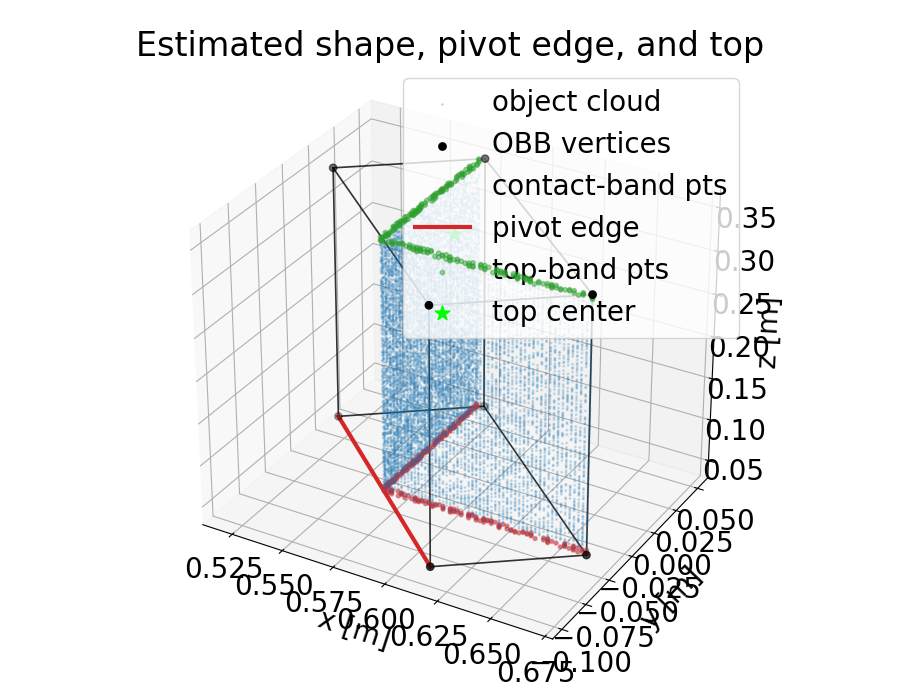

In [26]:
# Estimate shape (OBB vertices), pivot edge, and top from object point cloud
def estimate_obb(points_xyz: np.ndarray):
    if points_xyz.shape[0] < 20:
        raise ValueError("Need at least 20 points to estimate object shape.")

    # Gravity-aligned OBB: lock local z-axis to world z for physical consistency on table
    z_axis = np.array([0.0, 0.0, 1.0], dtype=float)

    # Estimate yaw from XY covariance
    xy = points_xyz[:, :2]
    mu_xy = xy.mean(axis=0)
    Y = xy - mu_xy
    Cxy = np.cov(Y.T)
    vals, vecs = np.linalg.eigh(Cxy)
    x_axis_xy = vecs[:, np.argmax(vals)]
    x_axis_xy = x_axis_xy / (np.linalg.norm(x_axis_xy) + 1e-12)
    y_axis_xy = np.array([-x_axis_xy[1], x_axis_xy[0]], dtype=float)

    x_axis = np.array([x_axis_xy[0], x_axis_xy[1], 0.0], dtype=float)
    y_axis = np.array([y_axis_xy[0], y_axis_xy[1], 0.0], dtype=float)

    axes = np.column_stack([x_axis, y_axis, z_axis])  # columns are local axes in world frame
    if np.linalg.det(axes) < 0:
        axes[:, 1] *= -1.0

    mean = points_xyz.mean(axis=0)
    local = (points_xyz - mean) @ axes
    mins = local.min(axis=0)
    maxs = local.max(axis=0)
    half_sizes = 0.5 * (maxs - mins)
    center_local = 0.5 * (maxs + mins)
    center_world = mean + center_local @ axes.T

    signs = np.array([
        [-1, -1, -1], [-1, -1,  1], [-1,  1, -1], [-1,  1,  1],
        [ 1, -1, -1], [ 1, -1,  1], [ 1,  1, -1], [ 1,  1,  1],
    ], dtype=float)

    verts_local = signs * half_sizes.reshape(1, 3)
    vertices = center_world.reshape(1, 3) + (verts_local @ axes.T)

    # Edge pairs in cube graph: vertices differing by exactly one sign bit
    edge_pairs = []
    for i in range(8):
        for j in range(i + 1, 8):
            if np.sum(signs[i] != signs[j]) == 1:
                edge_pairs.append((i, j))

    return {
        "center": center_world,
        "axes": axes,
        "half_sizes": half_sizes,
        "vertices": vertices,
        "edge_pairs": edge_pairs,
        "signs": signs,
    }

def _bottom_face_edges_from_obb(obb):
    verts = obb["vertices"]
    signs = obb["signs"]

    # Bottom face corresponds to local z sign = -1
    bottom_idx = np.where(signs[:, 2] < 0)[0].tolist()
    bottom_set = set(bottom_idx)

    # Candidate bottom edges are cube edges fully contained in bottom face
    candidate_edges = []
    for i, j in obb["edge_pairs"]:
        if i in bottom_set and j in bottom_set:
            candidate_edges.append((i, j))

    return bottom_idx, candidate_edges

def _point_line_distance_xy(Pxy: np.ndarray, axy: np.ndarray, bxy: np.ndarray):
    d = bxy - axy
    n = np.linalg.norm(d)
    if n < 1e-12:
        return np.linalg.norm(Pxy - axy.reshape(1, 2), axis=1)
    d = d / n
    proj = ((Pxy - axy.reshape(1, 2)) @ d).reshape(-1, 1) * d.reshape(1, 2)
    perp = (Pxy - axy.reshape(1, 2)) - proj
    return np.linalg.norm(perp, axis=1)

def estimate_pivot_edge(points_xyz: np.ndarray, obb, contact_band: float = 0.004, line_tol: float = 0.004):
    if points_xyz.shape[0] < 20:
        return None

    z_min = float(np.min(points_xyz[:, 2]))
    contact = points_xyz[points_xyz[:, 2] <= z_min + contact_band]
    if contact.shape[0] < 15:
        return None

    _, bottom_edges = _bottom_face_edges_from_obb(obb)
    verts = obb["vertices"]
    if len(bottom_edges) == 0:
        return None

    # Score each bottom edge by how many contact points lie close to that line in XY
    best = None
    best_score = (-1, -1.0)
    for i, j in bottom_edges:
        a = verts[i]
        b = verts[j]
        dist_xy = _point_line_distance_xy(contact[:, :2], a[:2], b[:2])
        support = int(np.sum(dist_xy < line_tol))
        length = float(np.linalg.norm((b - a)[:2]))
        score = (support, length)
        if score > best_score:
            best = (i, j, a, b, support, length)
            best_score = score

    if best is None:
        return None

    i, j, a, b, support, length = best
    return a, b, contact, (i, j, support, length)

def estimate_top(points_xyz: np.ndarray, top_band: float = 0.004):
    if points_xyz.shape[0] == 0:
        return None

    z_max = float(np.max(points_xyz[:, 2]))
    top_pts = points_xyz[points_xyz[:, 2] >= z_max - top_band]
    if top_pts.shape[0] == 0:
        return None

    top_center = top_pts.mean(axis=0)
    top_peak = points_xyz[np.argmax(points_xyz[:, 2])]
    return top_center, top_peak, top_pts

# NOTE on SAM: in simulation we already have exact instance masks from MuJoCo segmentation.
# SAM is most useful for real RGB images. We can still add it later as an optional branch if needed.
obb = estimate_obb(pc_world_obj)
pivot = estimate_pivot_edge(pc_world_obj, obb=obb, contact_band=0.006, line_tol=0.005)
top = estimate_top(pc_world_obj, top_band=0.006)

verts = obb["vertices"]
edge_pairs = obb["edge_pairs"]

print("Estimated OBB half-sizes [m]:", np.round(obb["half_sizes"], 4))
if pivot is not None:
    p1, p2, contact_pts, pmeta = pivot
    print("Pivot edge length [m]:", float(np.linalg.norm(p2 - p1)))
    print("Pivot edge support points:", pmeta[2])
else:
    print("Pivot edge: not enough near-table points.")

if top is not None:
    top_center, top_peak, top_pts = top
    print("Top z [m] (peak):", float(top_peak[2]))
else:
    print("Top: not enough top points.")

# Visualization
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(1, 1, 1, projection='3d')

# Object cloud
ax.scatter(pc_world_obj[:, 0], pc_world_obj[:, 1], pc_world_obj[:, 2], s=1.2, alpha=0.18, label='object cloud')

# OBB vertices + edges
ax.scatter(verts[:, 0], verts[:, 1], verts[:, 2], s=28, c='k', label='OBB vertices')
for i, j in edge_pairs:
    e = np.vstack([verts[i], verts[j]])
    ax.plot(e[:, 0], e[:, 1], e[:, 2], c='k', linewidth=1.2, alpha=0.8)

# Contact points + pivot edge
if pivot is not None:
    ax.scatter(contact_pts[:, 0], contact_pts[:, 1], contact_pts[:, 2], s=8, c='tab:red', alpha=0.45, label='contact-band pts')
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], c='tab:red', linewidth=3.0, label='pivot edge')

# Top points + top marker
if top is not None:
    ax.scatter(top_pts[:, 0], top_pts[:, 1], top_pts[:, 2], s=10, c='tab:green', alpha=0.45, label='top-band pts')
    ax.scatter([top_center[0]], [top_center[1]], [top_center[2]], s=120, c='lime', marker='*', label='top center')

ax.set_title('Estimated shape, pivot edge, and top')
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.legend(loc='upper right')
ax.set_box_aspect((1.2, 1.0, 1.0))
plt.tight_layout()
plt.show()

## Perception Loop (Temporal)
Runs a short loop, captures point clouds from `depth_cam`, and overlays object points over time for quick validation.

Captured 20 point-cloud frames from depth_cam


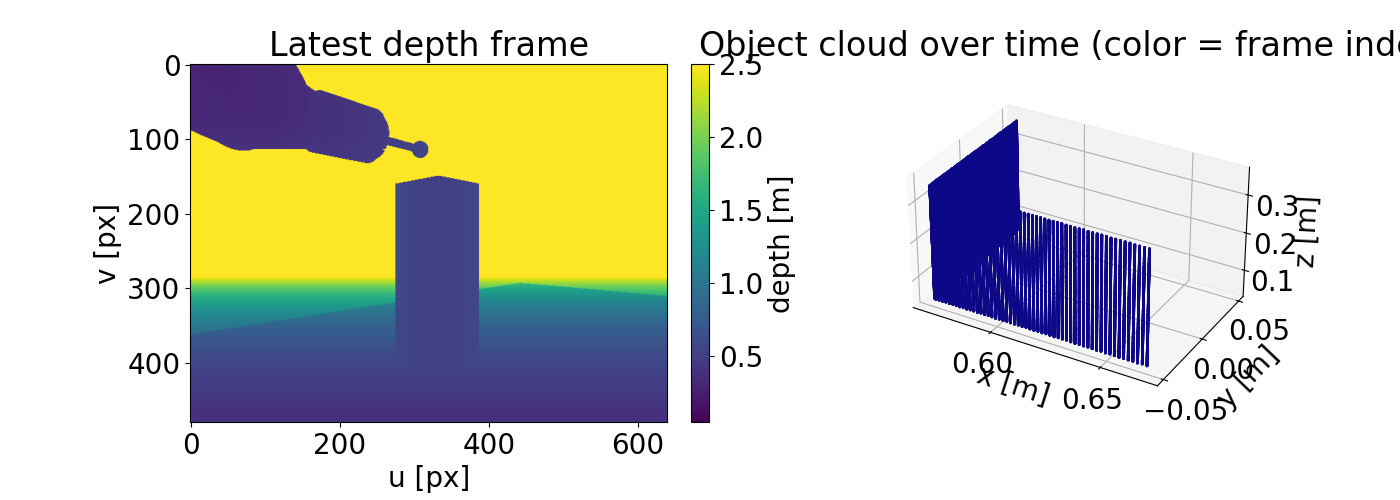

In [27]:
# Temporal point-cloud capture loop from fixed camera
PC_LOOP_STEPS = 400
PC_CAPTURE_EVERY = 20

obj_cloud_hist = []
depth_hist = []

R_wc, p_wc, cam_id = _get_camera_pose_world(model, data, PC_CAM_NAME)
fx, fy, cx, cy = _get_intrinsics_from_fovy(model, cam_id, PC_W, PC_H)

for k in range(PC_LOOP_STEPS):
    # Keep the simulation running; replace with your controller call if needed
    mujoco.mj_step(model, data)

    if k % PC_CAPTURE_EVERY != 0:
        continue

    depth_img = capture_depth_image(model, data, pc_renderer, PC_CAM_NAME)
    seg_img = capture_segmentation(pc_renderer, data, PC_CAM_NAME)

    try:
        target_geom_id = model.geom('payload').id
    except Exception:
        target_geom_id = model.ngeom - 1

    obj_mask = _geom_mask_from_seg(seg_img, target_geom_id)
    pc_world_obj = depth_to_world_pointcloud(
        depth_img, R_wc, p_wc, fx, fy, cx, cy,
        stride=PC_STRIDE, z_min=PC_Z_MIN, z_max=PC_Z_MAX, pixel_mask=obj_mask, max_points=PC_MAX_POINTS,
    )

    if pc_world_obj.shape[0] > 0:
        obj_cloud_hist.append(pc_world_obj)
        depth_hist.append(depth_img)

print(f"Captured {len(obj_cloud_hist)} point-cloud frames from {PC_CAM_NAME}")

# Visualize: last depth + accumulated object point cloud over time
fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1)
if len(depth_hist) > 0:
    im = ax1.imshow(depth_hist[-1], cmap='viridis', vmin=PC_Z_MIN, vmax=min(PC_Z_MAX, np.nanpercentile(depth_hist[-1], 99)))
    plt.colorbar(im, ax=ax1, fraction=0.046, pad=0.04, label='depth [m]')
ax1.set_title('Latest depth frame')
ax1.set_xlabel('u [px]')
ax1.set_ylabel('v [px]')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
if len(obj_cloud_hist) > 0:
    for i, p in enumerate(obj_cloud_hist):
        c = np.full((p.shape[0],), i)
        ax2.scatter(p[:, 0], p[:, 1], p[:, 2], c=c, cmap='plasma', s=1.0, alpha=0.35)

ax2.set_title('Object cloud over time (color = frame index)')
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
ax2.set_zlabel('z [m]')
ax2.set_box_aspect((1.5, 1.0, 0.8))

plt.tight_layout()
plt.show()

In [45]:
# Friction sanity check (tangent coefficient between object and table).
table_geom_id = model.geom('table').id
mu_table_tangent = float(model.geom_friction[table_geom_id, 0])

# Use explicit payload geom name when present; fallback is last geom.
try:
    payload_geom_id = model.geom('payload').id
except Exception:
    payload_geom_id = model.ngeom - 1

payload_geom_name = model.geom(payload_geom_id).name
mu_obj_tangent = float(model.geom_friction[payload_geom_id, 0])

# MuJoCo uses the higher-priority geom if present; otherwise it takes the element-wise max.
mu_obj_table_tangent = float(max(mu_table_tangent, mu_obj_tangent))

In [46]:
# # ====== OPTIONAL: Save all simulation variables to numpy file ======
# # This captures all the data collected during the simulation loop
# # Useful when you want to preserve force/pose history even if not using trajectory recorder

np.savez(
    "simulation_data.npz",
    t_hist=t_hist,
    w_hist=w_hist,                    # Force/torque at each step (N, Nm)
    quat_hist=quat_hist,              # Object quaternion at each step
    ball_pose_hist=ball_pose_hist,    # Ball-center pose (4x4 transforms)
    sens_pose_hist=sens_pose_hist,    # FT sensor pose (4x4 transforms)
    con_bool_hist=con_bool_hist,      # Contact status at each step
    obj_pose_hist=obj_pose_hist,      # Object pose (4x4 transforms)
    ball_pos_hist=ball_pos_hist,      # Ball position trajectory
    sens_pos_hist=sens_pos_hist,      # Sensor position trajectory
    obj_pos_hist=obj_pos_hist,        # Object position trajectory
    com_gt=com_GT,                    # Ground truth center of mass (3,)
    mass_gt=mass_GT,                  # Ground truth mass
    mu_gt=mu_obj_table_tangent        # Effective tangent friction coefficient between object and table
)
print("Saved all simulation data to simulation_data.npz")

Saved all simulation data to simulation_data.npz
